# 21_04 — Evaluación predictiva · Datos reales

Paso **3b** del ciclo. Supone que `21_03_convergencia` dio veredicto ✓; si las
cadenas no convergieron, nada de lo que sigue significa algo.


## Qué se reporta

| Sección | Qué responde |
|---|---|
| 4 | métricas puntuales y distribucionales, **train vs test** |
| 5 | bandas de credibilidad sobre la serie de cada score |
| 6 | intervalos sobre la curva, en extractos cada 10 períodos |
| 7 | ventana móvil: cómo evoluciona el error al cruzar $T_0$ |
| 8 | calibración: PIT por bloque |

Todo el cálculo vive en `fit/` y todo el dibujo en `graphics/`: este notebook
sólo orquesta.

## 1. Imports, rutas y artefactos

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import loadmat

from model_psbp_fd.pipelines import (
    cargar_curvas, cargar_curvas_true, cargar_fpca, cargar_estandarizador,
    cargar_datasets_ar, cargar_hiperparametros, cargar_config_evaluacion,
)
from model_psbp_fd.functions_models import DataStandardizer
from model_psbp_fd.models.pspb_fd_v3 import (
    PSBPPredictor, PropagadorFuncional, residuos_representacion,
)

from model_psbp_fd.fit import (
    # puntual
    rmse_por_coeficiente, r2_por_columna, razon_dispersion, mise, rmse_funcional,
    # distribucional muestral
    crps_muestral, energy_score, cobertura, intervalo_muestral,
    pit_muestral, diagnostico_pit,
    # agrupación de cadenas y ventana móvil
    agrupar_momentos, ventana_movil_scores, ventana_movil_funcional,
)
from model_psbp_fd.graphics import (
    plot_ventana_movil, plot_bandas_serie, plot_extractos_curvas,
    plot_calibracion_pit, plot_scatter_theta,
)
from model_psbp_fd.utils import get_project_root

plt.style.use("seaborn-v0_8-darkgrid")
%matplotlib inline

In [2]:
PROJECT_ROOT = get_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# [CONFIG] debe coincidir con 21_01, 21_03 y 21_05 y con psbp_fd_iteracion.m
BASENAME   = "real"
SERIE_ID   = "nivel"    # variable modelada; ver VARIABLE en 21_01 §2.1
VENTANA_ID = 2          # ventana temporal; cambiarla NO pisa artefactos previos
M_FPCA     = 3          # [BARRIDO] debe ser el mismo en los cuatro notebooks

EXPERIMENT_ID = f"{BASENAME}_{SERIE_ID}_v{VENTANA_ID:02d}_m{M_FPCA:02d}"

PATHS = {
    "raw":          PROJECT_ROOT / "data" / "reales" / "raw" / EXPERIMENT_ID,
    "functional":   PROJECT_ROOT / "data" / "reales" / "processed" / "functional" / EXPERIMENT_ID,
    "predict":      PROJECT_ROOT / "data" / "reales" / "processed" / "predict" / EXPERIMENT_ID,
    "out_report":   PROJECT_ROOT / "reports" / "reales" / EXPERIMENT_ID,
    "out_artefact": PROJECT_ROOT / "artefact" / "reales" / EXPERIMENT_ID,
}
for r in PATHS.values():
    r.mkdir(parents=True, exist_ok=True)
print(f"EXPERIMENT_ID : {EXPERIMENT_ID}")


EXPERIMENT_ID : real_nivel_v01_m03


In [3]:
dfs_train, manifest = cargar_datasets_ar(PATHS, bloque="train")
dfs_test,  _        = cargar_datasets_ar(PATHS, bloque="test")
hp_json     = cargar_hiperparametros(PATHS)
eval_config = cargar_config_evaluacion(PATHS)

COMPONENT_IDX = manifest["component_idx"]
n_components  = len(COMPONENT_IDX)
cov_names     = manifest["cov_names"]
N_LAGS        = int(manifest["n_lags"])
T, T0         = int(manifest["T"]), int(manifest["T0"])
N_ITER        = int(hp_json["n_iter"])
MCMC_CFG      = hp_json["mcmc_config"]
BURN          = int(MCMC_CFG["burn"])

assert manifest["scores_scale"] == "standardized_zscore_ddof0"

# Parámetros de evaluación: se LEEN del artefacto, no se redeclaran aquí.
NIVEL        = float(eval_config.get("nivel_credibilidad", 0.95))
MODO_RESIDUO = eval_config.get("modo_residuo", "ninguno")
OBJETIVO     = eval_config.get("objetivo_evaluacion", "curva_verdadera")
VENTANAS_W   = list(eval_config.get("ventana_movil", {}).get("w", [10, 20, 40]))

print(f"T={T}  T0={T0}  n_lags={N_LAGS}  componentes={n_components}")
print(f"nivel={NIVEL}  ·  modo_residuo={MODO_RESIDUO!r}  ·  objetivo={OBJETIVO!r}")
print(f"ventanas w = {VENTANAS_W}")

T=400  T0=280  n_lags=1  componentes=3
nivel=0.95  ·  modo_residuo='empirico'  ·  objetivo='curva_observada'
ventanas w = [10, 20, 40]


In [4]:
fpca = cargar_fpca(PATHS)
_ver = fpca.verificar()
assert _ver["todo_ok"], f"Las identidades FPCA no se cumplen: {_ver}"

scores_standardizer = cargar_estandarizador(PATHS, DataStandardizer)
X_obs, grilla = cargar_curvas(PATHS)                 # (T, G) observada

# No hay curva sin ruido: `cargar_curvas_true` devuelve None y el objetivo de
# evaluación es la curva OBSERVADA. Se conserva el nombre `X_true` para que el
# resto del notebook sea idéntico al de simulación, pero apunta al dato.
_X_sin_ruido = cargar_curvas_true(PATHS, estricto=False)
assert _X_sin_ruido is None or OBJETIVO == "curva_verdadera"
X_true = X_obs if OBJETIVO == "curva_observada" else _X_sin_ruido
assert X_true is not None, (
    f"objetivo_evaluacion={OBJETIVO!r} exige la curva verdadera y no está "
    "persistida.")

M_fpca   = fpca.M
Psi_grid, mu_grid = fpca.Psi_grid, fpca.mu_grid
SCORES     = fpca.SCORES                              # (T, M) escala original
SCORES_STD = scores_standardizer.transform(SCORES)

print(f"FPCA M={M_fpca} K={fpca.K}   ·   curvas {X_true.shape}  grilla {grilla.shape}")
print(f"objetivo de evaluación: {OBJETIVO!r}  ·  residuo: {MODO_RESIDUO!r}")
print("   ← contra la curva observada: el error incluye el ruido de medición,")
print("     que ningún modelo puede predecir. No comparable con las")
print("     simulaciones, medidas contra X_t(tau).")
assert COMPONENT_IDX == list(range(M_fpca)), (
    "La propagación funcional necesita el vector completo de scores en orden; "
    f"COMPONENT_IDX={COMPONENT_IDX} y M={M_fpca}.")

FPCA M=3 K=10   ·   curvas (400, 49)  grilla (49,)
objetivo de evaluación: 'curva_observada'  ·  residuo: 'empirico'
   ← contra la curva observada: el error incluye el ruido de medición,
     que ningún modelo puede predecir. No comparable con las
     simulaciones, medidas contra X_t(tau).


## 2. Trazas MCMC

In [5]:
def ruta_traza(fpc_idx, chain):
    return PATHS["out_artefact"] / f"chain_fpc_{fpc_idx}_iter{chain:02d}.mat"


def leer_traza(path):
    m = loadmat(str(path))
    claves = ["betajhout", "beta0hout", "tauhout", "alphahout", "psijhout",
              "Gammajhout", "gammajhout", "pijout", "wjout", "osumout", "inEout"]
    traces = {k: np.asarray(m[k], dtype=np.float64) for k in claves}
    burn = int(np.asarray(m["burn"]).ravel()[0])
    feat = str(np.atleast_1d(m["feature_names"]).ravel()[0]).split(",")
    return traces, burn, feat


class ModeloTraza:
    def __init__(self, traces, burn, feature_names):
        self.traces = traces
        self.feature_names_ = list(feature_names)
        self.burn = int(burn)
        self.predictor_ = PSBPPredictor(traces=traces, burn=burn)

    def _diseno(self, df):
        Xp = np.asarray(df.iloc[:, 1:], dtype=float)
        return np.hstack([np.ones((Xp.shape[0], 1)), Xp])

    def momentos(self, df):
        return self.predictor_.momentos_predictivos(self._diseno(df))

    def muestrear(self, df, d=1, seed=None):
        return self.predictor_.muestrear(self._diseno(df), d, seed=seed)


faltan = [ruta_traza(COMPONENT_IDX[k] + 1, c + 1).name
          for k in range(n_components) for c in range(N_ITER)
          if not ruta_traza(COMPONENT_IDX[k] + 1, c + 1).exists()]
assert not faltan, f"Faltan trazas: {faltan}. Ejecuta psbp_fd_iteracion.m."

models_chains = {k: {} for k in range(n_components)}
for k in range(n_components):
    esperado = list(dfs_train[k].columns[1:])
    for c in range(N_ITER):
        traces, burn, feat = leer_traza(ruta_traza(COMPONENT_IDX[k] + 1, c + 1))
        assert feat == esperado, f"[k={k} c={c+1}] feature_names ≠ columnas del dataset."
        models_chains[k][c] = ModeloTraza(traces, burn, feat)

n_post = MCMC_CFG["nsim"] - BURN
print(f"✓ {n_components} × {N_ITER} cadenas · {n_post} draws posteriores c/u")

✓ 3 × 3 cadenas · 1500 draws posteriores c/u


## 3. Predicción a $h=1$ sobre la serie completa

Los dos bloques se concatenan en **una sola serie de orígenes**
$t=N_{lags}+1,\dots,T$. Ésa es la diferencia con el flujo anterior, que sólo
evaluaba el bloque de prueba: sin el tramo de entrenamiento no hay con qué
comparar el salto en $T_0$, que es la lectura principal de la ventana móvil.

En todos los orígenes la predicción usa los **rezagos reales** —nunca
predicciones encadenadas—, de modo que el horizonte es 1 en todo el recorrido y
el modelo no se reentrena en ningún punto.

In [6]:
# Número de extracciones de la predictiva por draw posterior. El total es
#     S = (nsim - burn) × S_POR_ITER × n_cadenas
# y d=1 ya da varios miles: subirlo sólo reduce el error Monte Carlo de estimar
# los cuantiles, no cambia la predictiva.

S_POR_ITER = 10
SEED_PRED  = 20260823

# Serie completa de orígenes: train (t = N_LAGS+1 … T0) seguido de test.
dfs_full = {k: pd.concat([dfs_train[k], dfs_test[k]], ignore_index=True)
            for k in range(n_components)}
n_orig   = len(dfs_full[0])
t_orig   = np.arange(N_LAGS + 1, T + 1)          # tiempo del experimento, base-1
assert len(t_orig) == n_orig, f"{len(t_orig)} ≠ {n_orig}"

# Índice del corte dentro de la serie de orígenes (los primeros N_LAGS no existen)
T0_orig  = T0 - N_LAGS
es_train = t_orig <= T0
print(f"orígenes evaluados: {n_orig}  (train {es_train.sum()} · test {(~es_train).sum()})")

_mem_gb = n_post * S_POR_ITER * N_ITER * n_orig * n_components * 4 / 1e9
print(f"SC_draws reservará {_mem_gb * 1e3:.0f} MB en float32")
assert _mem_gb < 2.0, (
    f"SC_draws pediría {_mem_gb:.1f} GB. Baja S_POR_ITER antes de continuar.")

orígenes evaluados: 399  (train 279 · test 120)
SC_draws reservará 215 MB en float32


In [7]:
# Momentos y extracciones por score, agrupando cadenas.
#   momentos : ley de varianza total entre cadenas (fit.agrupar_momentos)
#   muestras : concatenación, que es la mezcla de igual peso
Y_obs  = np.column_stack([dfs_full[k].iloc[:, 0].to_numpy() for k in range(n_components)])
Y_hat  = np.empty_like(Y_obs)
Y_sd   = np.empty_like(Y_obs)

S_POR_CADENA = n_post * S_POR_ITER
S_total      = S_POR_CADENA * N_ITER
SC_draws     = np.empty((S_total, n_orig, n_components), dtype=np.float32)

for k in range(n_components):
    medias, sds = [], []
    for j, c in enumerate(sorted(models_chains[k])):
        mom = models_chains[k][c].momentos(dfs_full[k])
        medias.append(mom["media"])
        sds.append(mom["sd"])            # PREDICTIVA (v3), no la del centro
        muestras_c = models_chains[k][c].muestrear(
            dfs_full[k], S_POR_ITER, seed=SEED_PRED + 1000 * k + c)
        assert muestras_c.shape == (S_POR_CADENA, n_orig), (
            f"[k={k} c={c}] muestrear devolvió {muestras_c.shape}; se esperaba "
            f"({S_POR_CADENA}, {n_orig}). ¿nsim/burn del .mat difieren del JSON?")
        SC_draws[j * S_POR_CADENA:(j + 1) * S_POR_CADENA, :, k] = muestras_c
        del muestras_c
    Y_hat[:, k], Y_sd[:, k] = agrupar_momentos(np.column_stack(medias),
                                               np.column_stack(sds))

li_s, ls_s = intervalo_muestral(SC_draws, nivel=NIVEL)   # (n_orig, M)

print(f"extracciones por score: S = {S_total} "
      f"= {n_post} draws × {S_POR_ITER} × {N_ITER} cadenas")
print(f"SC_draws {SC_draws.shape} {SC_draws.dtype} "
      f"({SC_draws.nbytes / 1e6:.0f} MB)  ·  bandas {li_s.shape}")

extracciones por score: S = 45000 = 1500 draws × 10 × 3 cadenas
SC_draws (45000, 399, 3) float32 (215 MB)  ·  bandas (399, 3)


### 3.1 Propagación a la curva

$\hat X^{(s)}_t(\tau)=\mu(\tau)+\sum_m (d_m\tilde\xi^{(s)}_{tm}+c_m)\psi_m(\tau)$,
que es (3.41) del documento. Con `modo_residuo="ninguno"` el mapa es
determinista y las curvas son extracciones exactas de la predictiva de la curva
**proyectada**.

Las muestras funcionales se **adelgazan** antes de propagar: el arreglo completo
sería $(S, n, G)$ y con $S$ de varios miles ocupa más de un gigabyte sin que los
cuantiles al 95 % mejoren de forma apreciable.

In [8]:
# Adelgazamiento para la propagación funcional. Con S_FUNC ≈ 500 el error
# Monte Carlo de un cuantil al 2.5% es del orden de 0.01 en escala de cuantil,
# despreciable frente al ancho de la banda.
S_FUNC = 500
paso_thin = max(1, S_total // S_FUNC)
SC_thin = SC_draws[::paso_thin]

# Residuo de representación, estimado SÓLO con el bloque de entrenamiento:
# con modo_residuo="empirico" la banda tiene que cubrir también lo que las M
# autofunciones no representan. Estimarlo con el test lo haría depender de
# aquello que se pretende evaluar.
residuos_train = None
if MODO_RESIDUO != "ninguno":
    residuos_train = residuos_representacion(X_obs[:T0],
                                             fpca.reconstruct(SCORES)[:T0])
    print(f"residuo de representación (train): sd media = "
          f"{residuos_train.std(axis=0, ddof=1).mean():.4f}   "
          f"({residuos_train.shape[0]} curvas)")

propagador = PropagadorFuncional(Psi_grid, mu_grid,
                                 estandarizador=scores_standardizer,
                                 residuos=residuos_train,
                                 modo_residuo=MODO_RESIDUO)
X_draws = propagador.curvas_desde_scores(SC_thin, seed=SEED_PRED)   # (S', n, G)
X_pred  = X_draws.mean(axis=0)                                       # (n, G)
li_f, ls_f = np.quantile(X_draws, (1 - NIVEL) / 2, axis=0), \
             np.quantile(X_draws, 1 - (1 - NIVEL) / 2, axis=0)

# Curvas de referencia alineadas a los orígenes evaluados
X_true_ev = X_true[N_LAGS:]     # (n_orig, G) OBSERVADA — contra esto se evalúa
X_obs_ev  = X_obs[N_LAGS:]      # (n_orig, G) observada, sólo para las figuras

print(f"muestras funcionales {X_draws.shape}  (adelgazado 1 de cada {paso_thin})")
print(f"memoria ≈ {X_draws.nbytes / 1e6:.0f} MB")

# Piso de error: la mejor curva alcanzable con M componentes, sin modelo alguno.
X_proj = fpca.reconstruct(SCORES)[N_LAGS:]
print(f"\nMISE del TRUNCAMIENTO (proyección FPCA de la curva observada): "
      f"{mise(X_true_ev, X_proj, grilla):.6f}")
print("   ← ningún modelo sobre esta representación puede bajar de ahí")

residuo de representación (train): sd media = 0.0105   (280 curvas)
muestras funcionales (500, 399, 49)  (adelgazado 1 de cada 90)
memoria ≈ 78 MB

MISE del TRUNCAMIENTO (proyección FPCA de la curva observada): 0.000111
   ← ningún modelo sobre esta representación puede bajar de ahí


## 4. Métricas, entrenamiento contra prueba

La comparación train/test es la que separa el ajuste de la generalización.
Con datos reales las dos columnas **no tienen por qué parecerse**: la serie
puede no ser estacionaria y el bloque de prueba corresponde a un período
posterior con su propia hidrología. Una degradación en $T_0$ es aquí un
resultado sobre la serie tanto como sobre el modelo, y §7 —la ventana móvil—
es lo que separa ambas lecturas.

In [9]:
def _metricas_bloque(mask, etiqueta):
    """Métricas puntuales y distribucionales sobre un subconjunto de orígenes."""
    filas = []
    for k in range(n_components):
        y, p = Y_obs[mask, k], Y_hat[mask, k]
        z    = SC_draws[:, mask, k]
        cob  = cobertura(y, li_s[mask, k], ls_s[mask, k])
        pit  = pit_muestral(y, z)
        filas.append({
            "bloque":  etiqueta,
            "FPC":     f"FPC {COMPONENT_IDX[k] + 1}",
            "RMSE":    float(rmse_por_coeficiente(y[:, None], p[:, None])[0]),
            "R2":      float(r2_por_columna(y[:, None], p[:, None], centrar=True)[0]),
            "sd_ratio": float(razon_dispersion(y[:, None], p[:, None])[0]),
            "CRPS":    float(crps_muestral(y, z).mean()),
            f"Cob{int(NIVEL*100)}": cob["cobertura"],
            "Ancho":   cob["ancho_medio"],
            "PIT_ks":  float(diagnostico_pit(pit)["ks"]),
            "PIT_forma": diagnostico_pit(pit)["forma"],
            "n":       int(mask.sum()),
        })
    return filas

met_df = pd.DataFrame(_metricas_bloque(es_train, "train")
                      + _metricas_bloque(~es_train, "test"))
met_df = met_df.set_index(["bloque", "FPC"])
met_df.to_csv(PATHS["out_report"] / "50_metricas_scores.csv")

_num = [c for c in met_df.columns if met_df[c].dtype.kind == "f"]
display(met_df.style
    .format({c: "{:.4f}" for c in _num})
    .background_gradient(subset=["RMSE", "CRPS"], cmap="RdYlGn_r")
    .background_gradient(subset=["R2"], cmap="RdYlGn", vmin=0, vmax=1)
    .background_gradient(subset=[f"Cob{int(NIVEL*100)}"], cmap="RdYlGn",
                         vmin=0.80, vmax=1.0)
    .set_caption("Métricas por score y bloque · CRPS y cobertura desde la "
                 "predictiva MUESTRAL"))

_deg = (met_df.loc["test", "RMSE"].mean() / met_df.loc["train", "RMSE"].mean())
print(f"\nRMSE test / RMSE train = {_deg:.3f}"
      + ("   ✓ sin degradación apreciable" if _deg < 1.15
         else "   ← el modelo se degrada fuera de muestra"))


RMSE test / RMSE train = 0.680   ✓ sin degradación apreciable


In [10]:
# Métricas funcionales, contra la curva OBSERVADA (no hay curva sin ruido)
filas_f = []
for mask, etq in ((es_train, "train"), (~es_train, "test")):
    dentro = (X_true_ev[mask] >= li_f[mask]) & (X_true_ev[mask] <= ls_f[mask])
    filas_f.append({
        "bloque": etq,
        "MISE":   mise(X_true_ev[mask], X_pred[mask], grilla),
        "RMSE_f": rmse_funcional(X_true_ev[mask], X_pred[mask], grilla),
        "MISE_truncamiento": mise(X_true_ev[mask], X_proj[mask], grilla),
        "energy": energy_score(X_true_ev[mask], X_draws[:, mask, :],
                               max_pares=2000, seed=0),
        f"Cob{int(NIVEL*100)}_puntual": float(dentro.mean()),
        "ancho_medio": float((ls_f[mask] - li_f[mask]).mean()),
        "n": int(mask.sum()),
    })
fun_df = pd.DataFrame(filas_f).set_index("bloque")
fun_df.to_csv(PATHS["out_report"] / "51_metricas_funcionales.csv")

display(fun_df.style.format("{:.6f}", subset=["MISE", "RMSE_f", "MISE_truncamiento"])
        .format("{:.4f}", subset=["energy", f"Cob{int(NIVEL*100)}_puntual", "ancho_medio"])
        .set_caption("Métricas funcionales contra la curva OBSERVADA · "
                     "banda sin residuo de representación"))

_frac = fun_df["MISE_truncamiento"] / fun_df["MISE"]
print("\nfracción del MISE atribuible al truncamiento FPCA:")
for b in fun_df.index:
    print(f"  {b:5s}: {_frac[b]:.1%}"
          + ("   ← el techo de la representación domina; subir M rinde más "
             "que mejorar el modelo" if _frac[b] > 0.7 else ""))
print(f"\nLa cobertura es PUNTUAL (cada tau por separado), NO simultánea sobre "
      f"la curva.")

,MISE,RMSE_f,MISE_truncamiento,energy,Cob95_puntual,ancho_medio,n
bloque,,,,,,,
train,0.000491,0.022148,0.000115,0.0851,0.9757,0.0986,279
test,0.000376,0.019380,0.000100,0.0853,0.9915,0.1181,120



fracción del MISE atribuible al truncamiento FPCA:
  train: 23.5%
  test : 26.6%

La cobertura es PUNTUAL (cada tau por separado), NO simultánea sobre la curva.


## 5. Bandas de credibilidad sobre la serie de scores

[plot_bandas_serie] inicio (3 pasos)
  1/3 (33.3%) t=0.0s eta=0.0s  FPC 1: cob train=0.961 (+0.011) test=0.983 (+0.033) | ancho train=0.6572 test=0.7847 | 13/399 fuera
  2/3 (66.7%) t=0.0s eta=0.0s  FPC 2: cob train=0.968 (+0.018) test=0.983 (+0.033) | ancho train=3.457 test=4.171 | 11/399 fuera
  3/3 (100.0%) t=0.0s eta=0.0s  FPC 3: cob train=0.964 (+0.014) test=0.983 (+0.033) | ancho train=2.34 test=2.376 | 12/399 fuera
[plot_bandas_serie] listo: 3 pasos en 0.9s  -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\reports\reales\real_nivel_v01_m03\52_bandas_scores.png


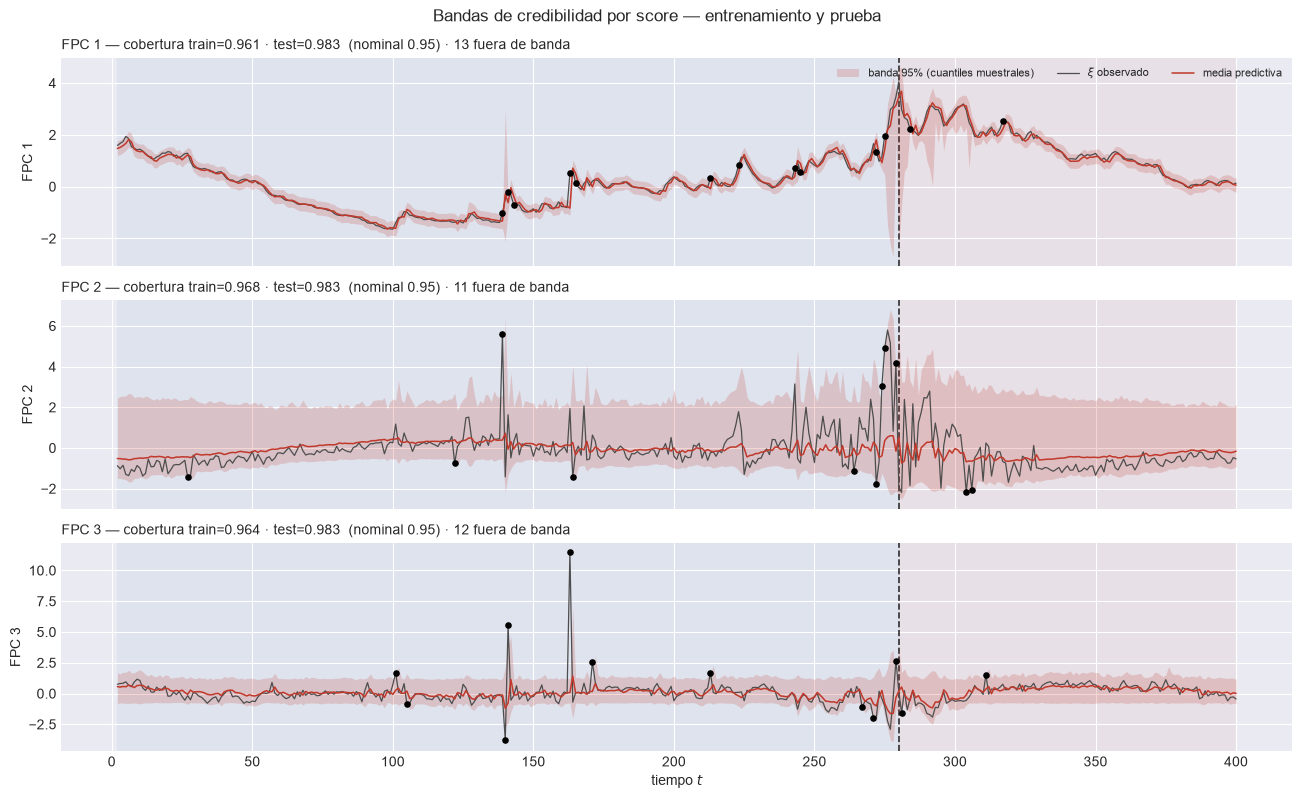

In [11]:
plot_bandas_serie(
    Y_obs, Y_hat, li_s, ls_s, T0, t=t_orig,
    etiquetas=[f"FPC {i + 1}" for i in COMPONENT_IDX], nivel=NIVEL,
    title="Bandas de credibilidad por score — entrenamiento y prueba",
    save_path=str(PATHS["out_report"] / "52_bandas_scores.png"),
    verbose=True)
plt.show()

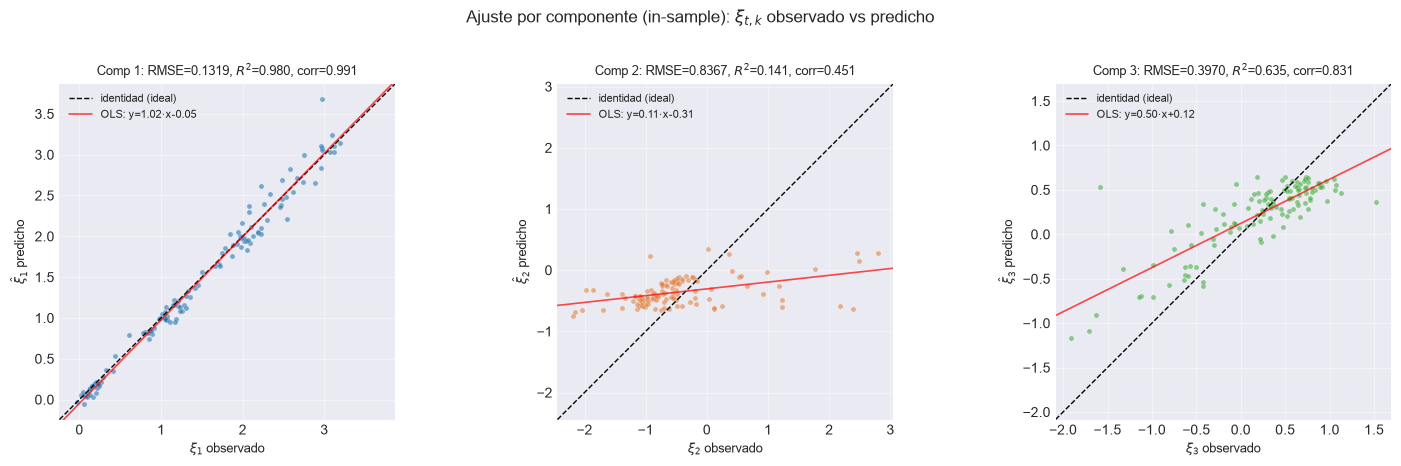

In [12]:
eval_scatter = {k: {"y_obs": Y_obs[~es_train, k], "y_hat": Y_hat[~es_train, k]}
                for k in range(n_components)}
plot_scatter_theta(eval_scatter, n_components=n_components,
                   save_path=str(PATHS["out_report"] / "53_scatter_scores_test.png"))
plt.show()

## 6. Intervalos de credibilidad sobre la curva

Extractos de la serie funcional cada `CADA` períodos, cada uno con su banda
puntual y la curva observada, para ver de un
vistazo dónde estaba el ruido que la banda **no** tiene que cubrir.

[plot_extractos_curvas] inicio (20 pasos)
  1/20 ( 5.0%) t=0.0s eta=0.1s  t=2 [train] cob=1.000 rmse=0.01789
  2/20 (10.0%) t=0.0s eta=0.1s  t=22 [train] cob=1.000 rmse=0.01012
  3/20 (15.0%) t=0.0s eta=0.1s  t=42 [train] cob=1.000 rmse=0.005789
  4/20 (20.0%) t=0.0s eta=0.1s  t=62 [train] cob=0.959 rmse=0.02295
  5/20 (25.0%) t=0.0s eta=0.1s  t=82 [train] cob=1.000 rmse=0.004451
  6/20 (30.0%) t=0.1s eta=0.1s  t=102 [train] cob=1.000 rmse=0.006238
  7/20 (35.0%) t=0.1s eta=0.1s  t=122 [train] cob=0.959 rmse=0.02327
  8/20 (40.0%) t=0.1s eta=0.1s  t=142 [train] cob=0.939 rmse=0.03721
  9/20 (45.0%) t=0.1s eta=0.1s  t=162 [train] cob=1.000 rmse=0.00683
  10/20 (50.0%) t=0.1s eta=0.1s  t=182 [train] cob=1.000 rmse=0.01316
  11/20 (55.0%) t=0.1s eta=0.1s  t=202 [train] cob=1.000 rmse=0.006633
  12/20 (60.0%) t=0.1s eta=0.1s  t=222 [train] cob=1.000 rmse=0.02241
  13/20 (65.0%) t=0.1s eta=0.1s  t=242 [train] cob=1.000 rmse=0.0151
  14/20 (70.0%) t=0.1s eta=0.1s  t=262 [train] cob=0.939 rms

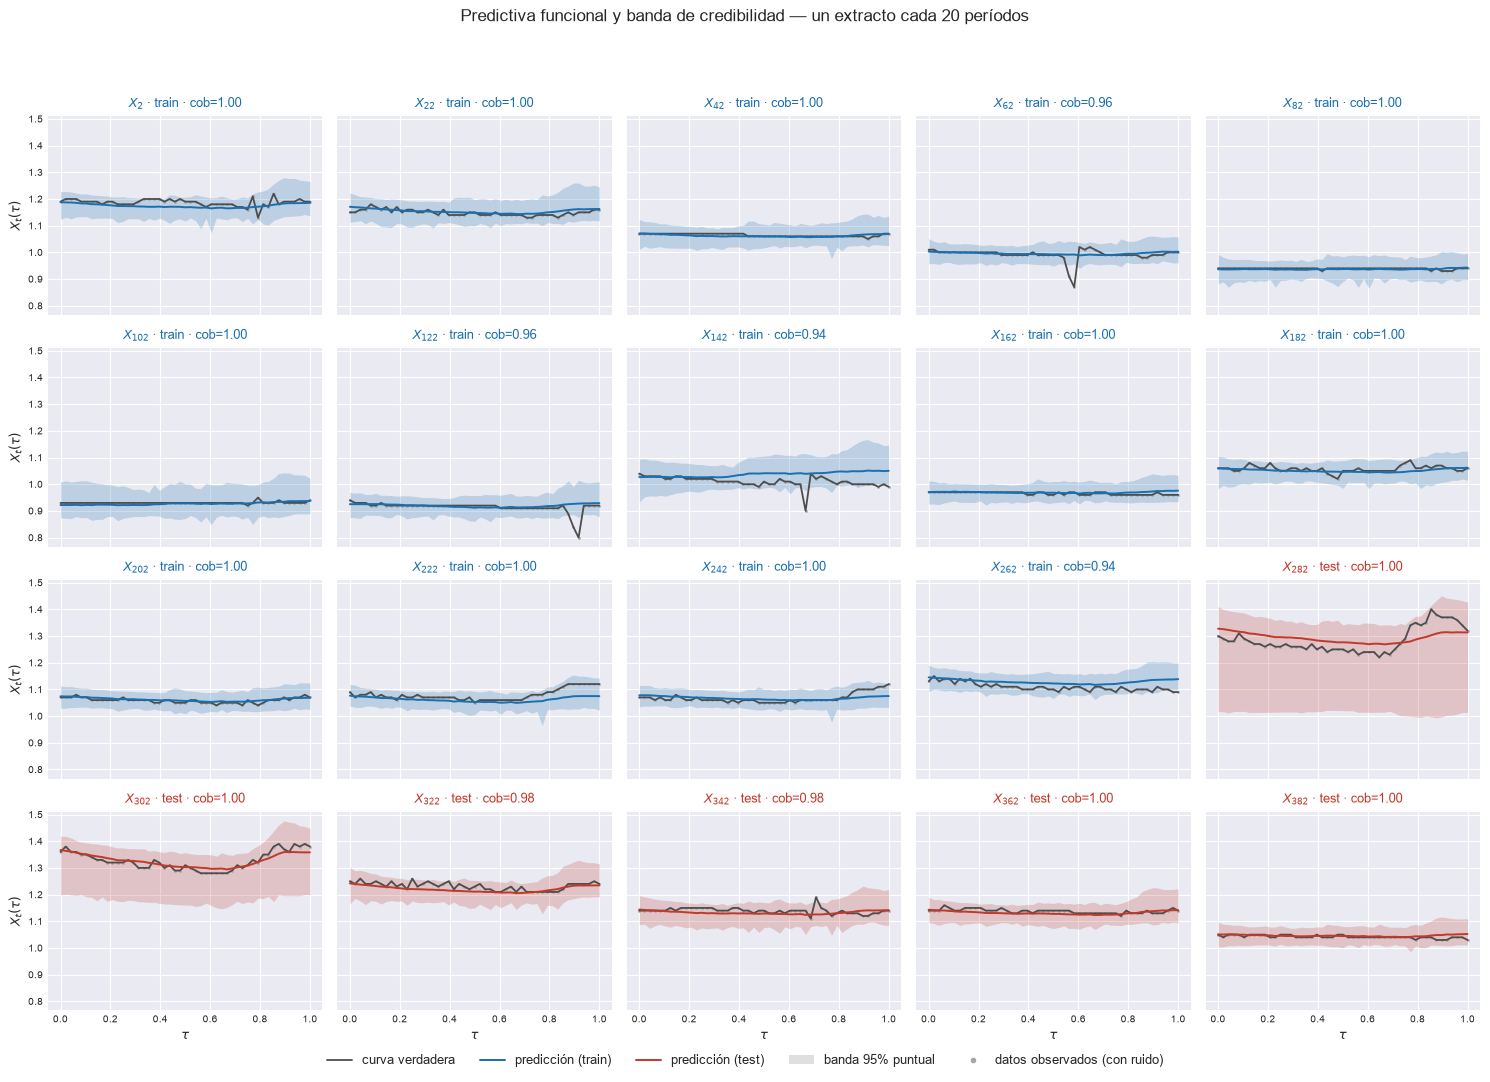

In [13]:
CADA = 20   # [CONFIG] un extracto cada CADA períodos

plot_extractos_curvas(
    X_true_ev, X_pred, li_f, ls_f, grilla, T0, t=t_orig,
    cada=CADA, n_col=5, nivel=NIVEL, X_obs=X_obs_ev,
    title="Predictiva funcional y banda de credibilidad",
    save_path=str(PATHS["out_report"] / "54_extractos_curvas.png"),
    verbose=True)
plt.show()

[plot_extractos_curvas] inicio (7 pasos)
  1/7 (14.3%) t=0.0s eta=0.0s  t=277 [train] cob=1.000 rmse=0.0788
  2/7 (28.6%) t=0.0s eta=0.0s  t=278 [train] cob=1.000 rmse=0.03007
  3/7 (42.9%) t=0.0s eta=0.0s  t=279 [train] cob=0.735 rmse=0.06899
  4/7 (57.1%) t=0.0s eta=0.0s  t=280 [train] cob=0.918 rmse=0.06642
  5/7 (71.4%) t=0.0s eta=0.0s  t=281 [test] cob=1.000 rmse=0.078
  6/7 (85.7%) t=0.0s eta=0.0s  t=282 [test] cob=1.000 rmse=0.03987
  7/7 (100.0%) t=0.0s eta=0.0s  t=283 [test] cob=1.000 rmse=0.0267
[plot_extractos_curvas] listo: 7 pasos en 0.9s  cob media train=0.913 test=1.000 (nominal 0.95)


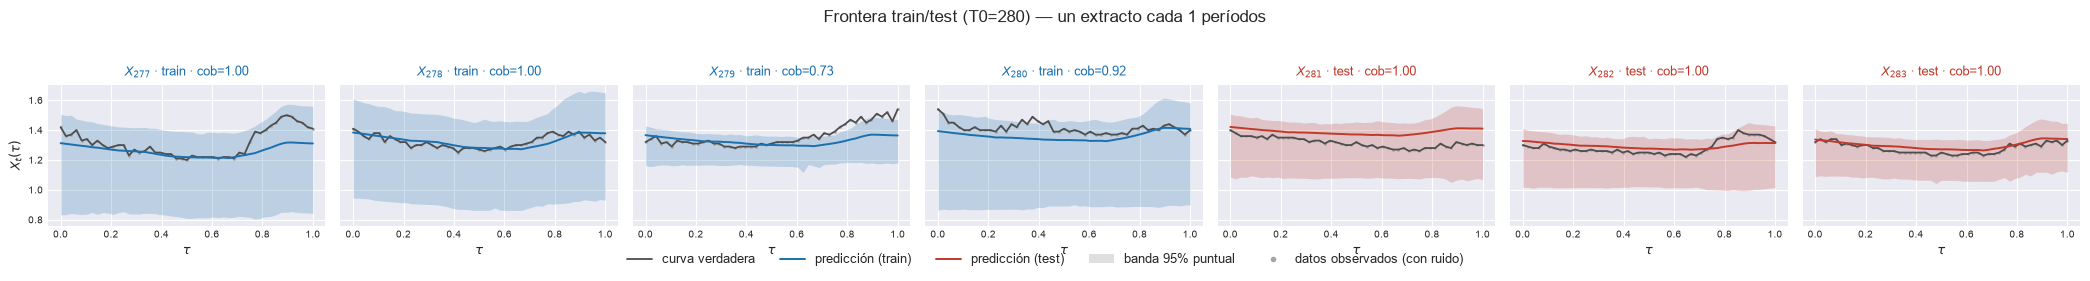

In [14]:
# Zoom sobre la frontera: los últimos orígenes de train y los primeros de test.
# Es donde se ve, curva a curva, si la banda se ensancha al salir de muestra.
i_corte = int(np.searchsorted(t_orig, T0))
sel = np.arange(max(0, i_corte - 3), min(n_orig, i_corte + 4))

plot_extractos_curvas(
    X_true_ev[sel], X_pred[sel], li_f[sel], ls_f[sel], grilla, T0,
    t=t_orig[sel], cada=1, n_col=len(sel), nivel=NIVEL, X_obs=X_obs_ev[sel],
    title=f"Frontera train/test (T0={T0})",
    save_path=str(PATHS["out_report"] / "55_extractos_frontera.png"),
    verbose=True)
plt.show()

## 7. Ventana móvil

El modelo **no se reentrena**: lo que se desliza es la ventana de evaluación.
Cada punto agrega las métricas de $w$ orígenes consecutivos, todos a $h=1$ con
los rezagos reales. Se superponen varios anchos para que la conclusión no
dependa de un $w$ elegido a dedo; las ventanas que **cruzan** $T_0$ van
punteadas, porque su cifra mezcla dentro y fuera de muestra.

[ventana_movil_scores[FPC 1, w=20]] inicio (380 pasos)
  1/380 ( 0.3%) t=0.0s eta=8.1s  t=11 [train] rmse=0.1174
  19/380 ( 5.0%) t=0.4s eta=8.3s  t=29 [train] rmse=0.08433
  38/380 (10.0%) t=0.9s eta=7.7s  t=48 [train] rmse=0.05466
  57/380 (15.0%) t=1.3s eta=7.1s  t=67 [train] rmse=0.03517
  76/380 (20.0%) t=1.6s eta=6.5s  t=86 [train] rmse=0.05453
  95/380 (25.0%) t=2.1s eta=6.2s  t=105 [train] rmse=0.09297
  114/380 (30.0%) t=2.4s eta=5.7s  t=124 [train] rmse=0.08196
  133/380 (35.0%) t=2.8s eta=5.3s  t=143 [train] rmse=0.1802
  152/380 (40.0%) t=3.2s eta=4.9s  t=162 [train] rmse=0.3373
  171/380 (45.0%) t=3.6s eta=4.5s  t=181 [train] rmse=0.04644
  190/380 (50.0%) t=4.0s eta=4.0s  t=200 [train] rmse=0.0879
  209/380 (55.0%) t=4.5s eta=3.6s  t=219 [train] rmse=0.1523
  228/380 (60.0%) t=5.1s eta=3.4s  t=238 [train] rmse=0.1236
  247/380 (65.0%) t=5.7s eta=3.1s  t=257 [train] rmse=0.1079
  266/380 (70.0%) t=6.2s eta=2.6s  t=276 [train] rmse=0.3431
  285/380 (75.0%) t=6.6s eta=2.2s  

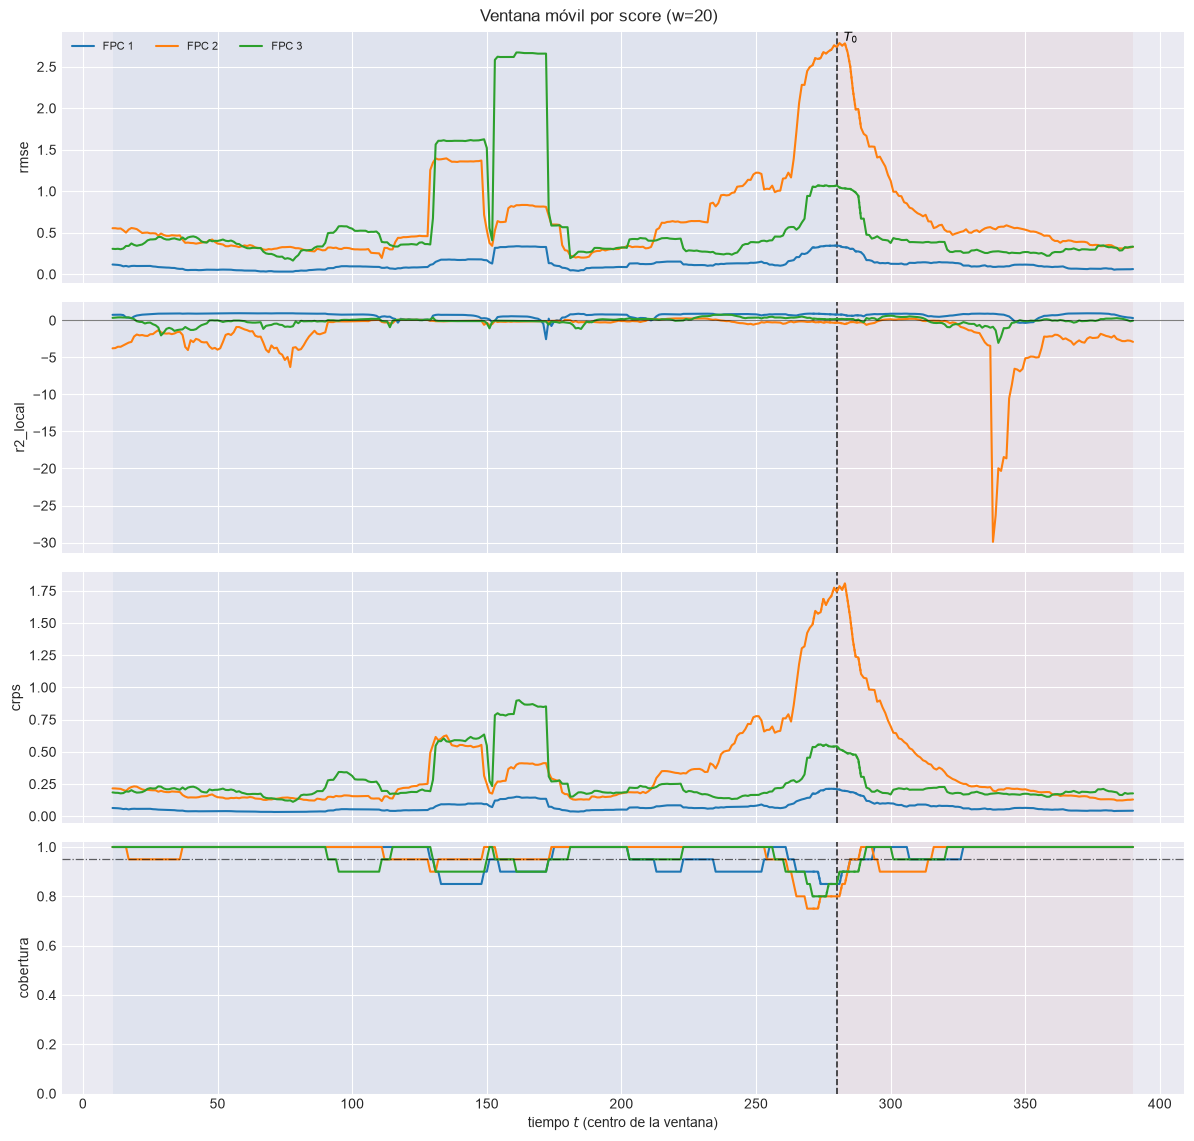

In [15]:
# `w_ref` se define antes del diccionario para pedir el progreso solo del
# ancho de referencia: con verbose en todos los anchos la salida serian
# cientos de lineas. Su valor es el mismo de antes.
w_ref = VENTANAS_W[len(VENTANAS_W) // 2]
tablas_score = {
    w: ventana_movil_scores(
        Y_obs, Y_hat, T0_orig, w=w, muestras=SC_draws, li=li_s, ls=ls_s,
        t_offset=N_LAGS,
        etiquetas=[f"FPC {i + 1}" for i in COMPONENT_IDX],
        verbose=(w == w_ref))
    for w in VENTANAS_W
}
tablas_score[w_ref].to_csv(PATHS["out_report"] / f"56_ventana_scores_w{w_ref}.csv",
                           index=False)

plot_ventana_movil(
    tablas_score[w_ref], T0, ["rmse", "r2_local", "crps", "cobertura"],
    columna_grupo="componente",
    title=f"Ventana móvil por score (w={w_ref})",
    save_path=str(PATHS["out_report"] / "56_ventana_scores.png"),
    verbose=True)
plt.show()

[ventana_movil_funcional[w=20]] inicio (380 pasos)
  1/380 ( 0.3%) t=0.0s eta=0.7s  t=11 [train] mise=0.0003289
  19/380 ( 5.0%) t=0.0s eta=0.1s  t=29 [train] mise=0.0002273
  38/380 (10.0%) t=0.0s eta=0.1s  t=48 [train] mise=0.0001598
  57/380 (15.0%) t=0.0s eta=0.1s  t=67 [train] mise=0.0001051
  76/380 (20.0%) t=0.0s eta=0.1s  t=86 [train] mise=9.476e-05
  95/380 (25.0%) t=0.0s eta=0.1s  t=105 [train] mise=0.0001849
  114/380 (30.0%) t=0.0s eta=0.0s  t=124 [train] mise=0.0001607
  133/380 (35.0%) t=0.0s eta=0.0s  t=143 [train] mise=0.000859
  152/380 (40.0%) t=0.0s eta=0.0s  t=162 [train] mise=0.00166
  171/380 (45.0%) t=0.0s eta=0.0s  t=181 [train] mise=6.689e-05
  190/380 (50.0%) t=0.0s eta=0.0s  t=200 [train] mise=0.0002741
  209/380 (55.0%) t=0.0s eta=0.0s  t=219 [train] mise=0.0004132
  228/380 (60.0%) t=0.0s eta=0.0s  t=238 [train] mise=0.0003327
  247/380 (65.0%) t=0.0s eta=0.0s  t=257 [train] mise=0.0003616
  266/380 (70.0%) t=0.0s eta=0.0s  t=276 [train] mise=0.002367
  285

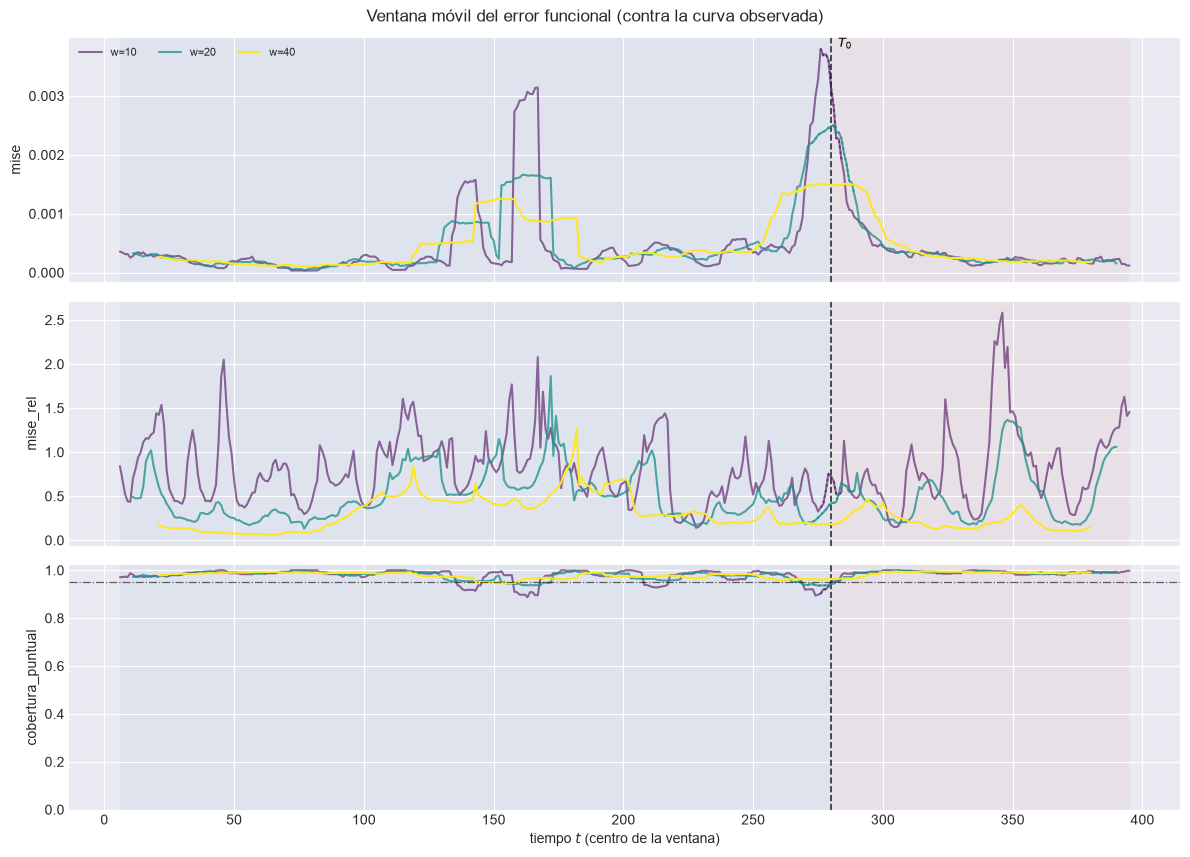

In [16]:
tablas_fun = {
    w: ventana_movil_funcional(X_true_ev, X_pred, grilla, T0_orig, w=w,
                               li=li_f, ls=ls_f, t_offset=N_LAGS,
                               verbose=(w == w_ref))
    for w in VENTANAS_W
}
tablas_fun[w_ref].to_csv(PATHS["out_report"] / f"57_ventana_funcional_w{w_ref}.csv",
                         index=False)

plot_ventana_movil(
    tablas_fun[w_ref], T0, ["mise", "mise_rel", "cobertura_puntual"],
    tablas_por_w=tablas_fun,
    title="Ventana móvil del error funcional (contra la curva observada)",
    save_path=str(PATHS["out_report"] / "57_ventana_funcional.png"),
    verbose=True)
plt.show()

In [17]:
# Lectura numérica del salto en T0, excluyendo las ventanas que lo cruzan.
print(f"{'w':>4}  {'MISE train':>11}  {'MISE test':>11}  {'salto':>7}")
print(f"{'─'*4}  {'─'*11}  {'─'*11}  {'─'*7}")
for w in VENTANAS_W:
    t_ = tablas_fun[w]
    limpio = t_[~t_["cruza_T0"]]
    a = limpio.loc[limpio.bloque == "train", "mise"].mean()
    b = limpio.loc[limpio.bloque == "test",  "mise"].mean()
    print(f"{w:>4}  {a:>11.6f}  {b:>11.6f}  {b/a:>6.2f}×")


   w   MISE train    MISE test    salto
────  ───────────  ───────────  ───────
  10     0.000436     0.000314    0.72×
  20     0.000413     0.000286    0.69×
  40     0.000404     0.000265    0.66×


## 8. Calibración

Bajo calibración perfecta el PIT es uniforme. La **forma** dice qué falla: una
U indica bandas demasiado angostas, una campana demasiado anchas, y una
pendiente un sesgo del centro. Contrastar train contra test separa el desajuste
del modelo de la pérdida de calibración fuera de muestra.

[plot_calibracion_pit] inicio (3 pasos)
  1/3 (33.3%) t=0.0s eta=0.1s  FPC 1  train: media=0.493 desv_max=0.935 n=279  |  test: media=0.521 desv_max=0.667 n=120
  2/3 (66.7%) t=0.0s eta=0.0s  FPC 2  train: media=0.501 desv_max=0.391 n=279  |  test: media=0.447 desv_max=0.667 n=120
  3/3 (100.0%) t=0.0s eta=0.0s  FPC 3  train: media=0.499 desv_max=0.398 n=279  |  test: media=0.543 desv_max=1.000 n=120
[plot_calibracion_pit] listo: 3 pasos en 0.5s  -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\reports\reales\real_nivel_v01_m03\58_pit.png


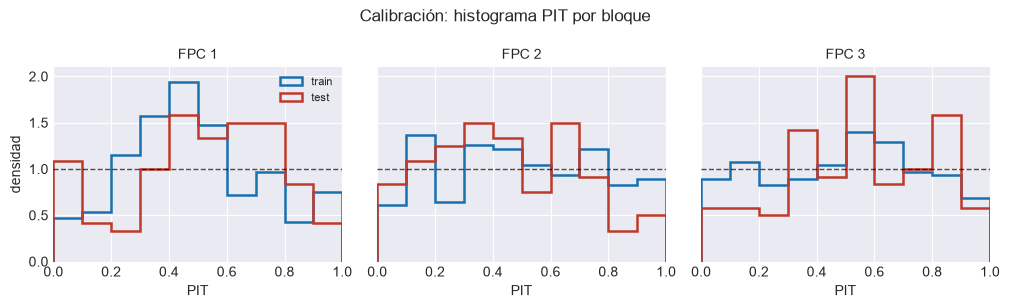

  FPC 1:  train KS=0.124 (aproximadamente uniforme)   test KS=0.136 (aproximadamente uniforme)
  FPC 2:  train KS=0.043 (aproximadamente uniforme)   test KS=0.131 (aproximadamente uniforme)
  FPC 3:  train KS=0.046 (aproximadamente uniforme)   test KS=0.140 (aproximadamente uniforme)


In [18]:
pit_tr = {f"FPC {COMPONENT_IDX[k]+1}": pit_muestral(Y_obs[es_train, k],
                                                    SC_draws[:, es_train, k])
          for k in range(n_components)}
pit_te = {f"FPC {COMPONENT_IDX[k]+1}": pit_muestral(Y_obs[~es_train, k],
                                                    SC_draws[:, ~es_train, k])
          for k in range(n_components)}

plot_calibracion_pit(pit_tr, pit_te,
                     save_path=str(PATHS["out_report"] / "58_pit.png"),
                     verbose=True)
plt.show()

for nombre in pit_tr:
    d_tr, d_te = diagnostico_pit(pit_tr[nombre]), diagnostico_pit(pit_te[nombre])
    print(f"  {nombre}:  train KS={d_tr['ks']:.3f} ({d_tr['forma']})   "
          f"test KS={d_te['ks']:.3f} ({d_te['forma']})")

## 9. Comparación con las líneas base

In [19]:
_bl = PATHS["out_report"] / "30_baselines_test.csv"
rmse_psbp = met_df.loc["test", "RMSE"].mean()
print(f"RMSE promedio en scores — PSBP-FD (test): {rmse_psbp:.4f}\n")

if _bl.exists():
    baselines_df = pd.read_csv(_bl, index_col=0)
    display(baselines_df.style.format("{:.4f}", na_rep="—")
            .set_caption("Líneas base sobre el bloque de prueba (h=1)"))
    if "RMSE_scores_prom" in baselines_df.columns:
        for modelo, fila in baselines_df.iterrows():
            marca = "✓ PSBP mejor" if rmse_psbp < fila["RMSE_scores_prom"] else "✗ baseline mejor"
            print(f"  vs {modelo:24s} RMSE={fila['RMSE_scores_prom']:.4f}  → {marca}")
else:
    print("⚠ falta 30_baselines_test.csv — ejecuta 21_01 §6.")


RMSE promedio en scores — PSBP-FD (test): 0.4552



,n_test,RMSE_fpc1,RMSE_fpc2,RMSE_fpc3,RMSE_scores_prom,R2_scores_prom,MISE,RMSE_funcional
modelo,,,,,,,,
media_incondicional,120.0000,1.7209,1.0268,0.6842,1.1440,-0.9329,0.0254,0.1593
persistencia_lag1,120.0000,0.1763,0.9616,0.4877,0.5419,0.4260,0.0005,0.0226


  vs media_incondicional      RMSE=1.1440  → ✓ PSBP mejor
  vs persistencia_lag1        RMSE=0.5419  → ✓ PSBP mejor


In [20]:
# ── Resumen ejecutable del experimento ───────────────────────────────────────
resumen = {
    "experiment_id": EXPERIMENT_ID,
    "objetivo_evaluacion": OBJETIVO,
    "modo_residuo": MODO_RESIDUO,
    "nivel": NIVEL,
    "S_scores": int(S_total), "S_funcional": int(X_draws.shape[0]),
    "rmse_scores_train": float(met_df.loc["train", "RMSE"].mean()),
    "rmse_scores_test":  float(met_df.loc["test", "RMSE"].mean()),
    "mise_train": float(fun_df.loc["train", "MISE"]),
    "mise_test":  float(fun_df.loc["test", "MISE"]),
    "mise_truncamiento_test": float(fun_df.loc["test", "MISE_truncamiento"]),
    f"cobertura_puntual_test": float(fun_df.loc["test", f"Cob{int(NIVEL*100)}_puntual"]),
}
pd.Series(resumen).to_csv(PATHS["out_report"] / "59_resumen.csv", header=False)
for k, v in resumen.items():
    print(f"  {k:26s}: {v}")
print(f"\nFiguras y tablas en {PATHS['out_report']}")

  experiment_id             : real_nivel_v01_m03
  objetivo_evaluacion       : curva_observada
  modo_residuo              : empirico
  nivel                     : 0.95
  S_scores                  : 45000
  S_funcional               : 500
  rmse_scores_train         : 0.6693853145796544
  rmse_scores_test          : 0.4551939011820225
  mise_train                : 0.0004905149256588431
  mise_test                 : 0.00037558793410775266
  mise_truncamiento_test    : 9.97489464020303e-05
  cobertura_puntual_test    : 0.9914965986394558

Figuras y tablas en C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\reports\reales\real_nivel_v01_m03
